In [1]:
"""Based partly on: 
    https://github.com/UnixJunkie/smi2sdf3d/blob/master/smi2sdf.py
    http://rdkit.org/UGM/2012/Ebejer_20110926_RDKit_1stUGM.pdf
    http://pubs.acs.org/doi/abs/10.1021/ci2004658
    https://greglandrum.github.io/rdkit-blog/posts/2024-02-11-more-multithreading.html

    Should try to sample all possible conformations based on dihedral angles sampling based on: https://github.com/dkoes/rdkit-scripts/blob/master/rdallconf.py
"""
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolAlign, rdMolTransforms, rdDistGeom
import math
import logging
logger = logging.getLogger('molsani')


def remove_nonpolar_hydrogens(mol):
    """
    Remove non-polar hydrogen atoms from the molecule.
    Returns a new molecule with only polar hydrogens retained.
    """
    # Create an editable mol object
    edit_mol = Chem.RWMol(mol)
    
    # Identify polar hydrogens
    polar_h_indices = set()
    for atom in edit_mol.GetAtoms():
        if atom.GetAtomicNum() == 1:  # It's a hydrogen
            neighbor = atom.GetNeighbors()[0]  # Get the atom it's bonded to
            if neighbor.GetAtomicNum() in [7, 8, 16]:  # N, O, or S
                polar_h_indices.add(atom.GetIdx())
    
    # Remove non-polar hydrogens
    atoms_to_remove = []
    for atom in edit_mol.GetAtoms():
        if atom.GetAtomicNum() == 1 and atom.GetIdx() not in polar_h_indices:
            atoms_to_remove.append(atom.GetIdx())
    
    # Remove atoms in reverse order to avoid index issues
    for idx in sorted(atoms_to_remove, reverse=True):
        edit_mol.RemoveAtom(idx)
    
    # Convert back to a regular mol object and return
    return edit_mol.GetMol()

def rmsd_filter(mol, ref_conf, conf_energies, threshold):
    """https://www.rdkit.org/docs/source/rdkit.Chem.AllChem.html#rdkit.Chem.AllChem.GetConformerRMS"""
    # we use heavy atoms RMSD; not all atoms (Peter Gedeck's suggestion)
    mol_noH = remove_nonpolar_hydrogens(mol)
    ref_conf_id = ref_conf.GetId()
    res = []
    for e, curr_conf in conf_energies:
        curr_conf_id = curr_conf.GetId()
        rms = AllChem.GetBestRMS(mol_noH, mol_noH, ref_conf_id, curr_conf_id, numThreads=0) #Use this to avoid the symmetrical problem
        if rms > threshold:
            res.append((e, curr_conf))
    return res

def write_to_sdf(mol, filename):
    with Chem.SDWriter(filename+'.sdf') as writer:
        for i, conf in enumerate(mol.GetConformers()):
            rdMolAlign.AlignMol(mol, mol, prbCid = conf.GetId(), refCid = 0)
            mol.SetProp("_Name", f"Conformer_{i+1}")
            writer.write(mol, confId=conf.GetId())

def getDihedralMatches(mol):
    '''return list of atom indices of dihedrals'''
    #this is rdkit's "strict" pattern
    pattern = r"*~[!$(*#*)&!D1&!$([CH3])&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])&!$([CD3](=[N,O,S])-!@[#7,O,S!D1])&!$([#7,O,S!D1]-!@[CD3]=[N,O,S])&!$([CD3](=[N+])-!@[#7!D1])&!$([#7!D1]-!@[CD3]=[N+])]-!@[!$(*#*)&!D1&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$([CH3])&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])]~*"
    qmol = Chem.MolFromSmarts(pattern)
    matches = mol.GetSubstructMatches(qmol);
    #these are all sets of 4 atoms, uniquify by middle two
    uniqmatches = []
    seen = set()
    for (a,b,c,d) in matches:
        if ((b,c) not in seen) and ((c,b) not in seen):
            seen.add((b,c))
            uniqmatches.append((a,b,c,d))
    return uniqmatches

def genConformer_r(mol, conf, i, matches,  sdwriter, product, degree = 30):
    '''recursively enumerate all angles for matches dihedrals.  i is where is
    which dihedral we are enumerating by degree to output conformers to out'''
    if i >= len(matches): #base case, torsions should be set in conf
        product.append(conf)
        #sdwriter.write(mol,conf)
        return product
    else:
        total = 0
        deg = 0
        while deg < 360.0:
            rad = math.pi*deg / 180.0
            rdMolTransforms.SetDihedralRad(mol.GetConformer(conf),*matches[i],value=rad)
            total += genConformer_r(mol, conf, i+1, matches, sdwriter, product, degree)
            deg += degree
        return product
    
def generate_conformers(smiles, name, rmsd = 0.25, randomSeed = 42, numConfs = 2000):

    params = rdDistGeom.ETKDGv3()
    params.numThreads = 0  # Use all available threads
    params.pruneRmsThresh = rmsd  # Prune conformations that are too similar
    params.randomSeed = randomSeed # For reproducible
    params.maxIterations = 20000

    mol = Chem.MolFromSmiles(smiles)
    mol_H = Chem.AddHs(mol)
    res = Chem.Mol(mol_H) # res = result molecule with conformations
    res.RemoveAllConformers() # An empty conformer list

    conf_energies = []
    
    #This part is for writing out sdf before optimization
    #print(len(mol_H.GetConformers())
    #write_to_sdf(mol_H, name+"_noopt")
    

    mp = Chem.rdForceFieldHelpers.MMFFGetMoleculeProperties(mol_H, mmffVariant="MMFF94s")
    mp.SetMMFFDielectricConstant(80)

    for cid in Chem.rdDistGeom.EmbedMultipleConfs(mol_H, numConfs=numConfs, params=params):
        ff = Chem.rdForceFieldHelpers.MMFFGetMoleculeForceField(mol_H, mp, confId = cid)
        ff.Minimize()
        energy = ff.CalcEnergy()
        conformer = mol_H.GetConformer(cid)
        conf_energies.append((energy, conformer))
    
    #write_to_sdf(mol_H, name+"_noopt")
    
    conf_energies = sorted(conf_energies, key = lambda x: x[0]) # sort by increasing E
    
    # This part is for outputing the minimized conformations
    while (len(conf_energies) > 0):
        energy, conformer = conf_energies.pop(0) # get the lowest energy conformer
        res.AddConformer(conformer, assignId = True) # add it to the conformations list
        conf_energies = rmsd_filter(mol_H, conformer, conf_energies, rmsd) # remove all conformers that are too similar to it

    print(f'{name}: before: {len(mol_H.GetConformers())}, after: {len(res.GetConformers())}')
    write_to_sdf(res, f'tricky_ligand_cleaned/{name}')

    """rotmatches = getDihedralMatches(res)
    total = 0
    while (len(conf_energies) > 0):
        energy, conformer = conf_energies.pop(0) # get the lowest energy conformer
        for m in rotmatches:
            rdMolTransforms.SetDihedralRad(conformer,*m,value=0) # set all dihedrals to 0
        res.AddConformer(conformer, assignId = True) # add it to the conformations list
        conf_energies = rmsd_filter(mol_H, conformer, conf_energies, rmsd) # remove all conformers that are too similar to it

    sdwriter = Chem.SDWriter(f"{name}_rotated.sdf")    
    for conf in range(len(res.GetConformers())):
        product = list(genConformer_r(res, conf, 0, rotmatches, sdwriter, degree=30))
        """    

def gen_conf_chunk(df: pd.DataFrame, rmsd: float, randomSeed: int, numConfs: int):
        for idx, row in df.iterrows():
            generate_conformers(row['smiles'], row['ids'], rmsd = rmsd, randomSeed = randomSeed, numConfs = numConfs)

In [2]:
df = pd.read_csv('tricky_ligands_new2_clean.smi', sep='\s+', names=['smiles', 'ids'], header=None)
gen_conf_chunk(df, rmsd = 0.25, randomSeed=200, numConfs=2000)


KeyboardInterrupt: 

In [3]:
"""Based partly on: 
    https://github.com/UnixJunkie/smi2sdf3d/blob/master/smi2sdf.py
    http://rdkit.org/UGM/2012/Ebejer_20110926_RDKit_1stUGM.pdf
    http://pubs.acs.org/doi/abs/10.1021/ci2004658
    https://greglandrum.github.io/rdkit-blog/posts/2024-02-11-more-multithreading.html

    Should try to sample all possible conformations based on dihedral angles sampling based on: https://github.com/dkoes/rdkit-scripts/blob/master/rdallconf.py
"""
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolAlign, rdMolTransforms, rdDistGeom
import numpy as np
import logging
logger = logging.getLogger('molsani')


def remove_nonpolar_hydrogens(mol):
    """
    Remove non-polar hydrogen atoms from the molecule.
    Returns a new molecule with only polar hydrogens retained.
    """
    # Create an editable mol object
    edit_mol = Chem.RWMol(mol)
    
    # Identify polar hydrogens
    polar_h_indices = set()
    for atom in edit_mol.GetAtoms():
        if atom.GetAtomicNum() == 1:  # It's a hydrogen
            neighbor = atom.GetNeighbors()[0]  # Get the atom it's bonded to
            if neighbor.GetAtomicNum() in [7, 8, 16]:  # N, O, or S
                polar_h_indices.add(atom.GetIdx())
    
    # Remove non-polar hydrogens
    atoms_to_remove = []
    for atom in edit_mol.GetAtoms():
        if atom.GetAtomicNum() == 1 and atom.GetIdx() not in polar_h_indices:
            atoms_to_remove.append(atom.GetIdx())
    
    # Remove atoms in reverse order to avoid index issues
    for idx in sorted(atoms_to_remove, reverse=True):
        edit_mol.RemoveAtom(idx)
    
    # Convert back to a regular mol object and return
    return edit_mol.GetMol()



def getDihedralMatches(mol):
    '''return list of atom indices of dihedrals'''
    #this is rdkit's "strict" pattern
    pattern = r"*~[!$(*#*)&!D1&!$([CH3])&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])&!$([CD3](=[N,O,S])-!@[#7,O,S!D1])&!$([#7,O,S!D1]-!@[CD3]=[N,O,S])&!$([CD3](=[N+])-!@[#7!D1])&!$([#7!D1]-!@[CD3]=[N+])]-!@[!$(*#*)&!D1&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$([CH3])&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])]~*"
    qmol = Chem.MolFromSmarts(pattern)
    matches = mol.GetSubstructMatches(qmol);
    #these are all sets of 4 atoms, uniquify by middle two
    uniqmatches = []
    seen = set()
    for (a,b,c,d) in matches:
        if ((b,c) not in seen) and ((c,b) not in seen):
            seen.add((b,c))
            uniqmatches.append((a,b,c,d))
    return uniqmatches


def check_too_close_nonbonded_atoms(conformer, mol, threshold=1.6):
    """
    Check if any non-bonded atoms in a given conformer are too close to each other.

    Parameters:
    conformer (rdkit.Chem.rdchem.Conformer): The RDKit conformer object.
    mol (rdkit.Chem.Mol): The RDKit molecule object.
    threshold (float): The distance threshold below which atoms are considered too close.

    Returns:
    bool: True if any non-bonded atoms are too close, False otherwise.
    """
    positions = conformer.GetPositions()
    
    # Get the number of atoms in the molecule
    num_atoms = mol.GetNumAtoms()
    
    # Iterate over all pairs of atoms
    for i in range(num_atoms):
        for j in range(i + 1, num_atoms):
            # Check if the atoms are bonded
            if not mol.GetBondBetweenAtoms(i, j):
                # Calculate the distance between the non-bonded atoms
                distance = np.linalg.norm(positions[i] - positions[j])
                if distance < threshold:
                    return True
    return False

def genConformer_r(mol, conf, i, matches,  sdwriter, product, original, degree = 60):
    '''recursively enumerate all angles for matches dihedrals.  i is where is
    which dihedral we are enumerating by degree to output conformers to out'''
    if len(product) > 2000: return product
    if i >= len(matches): #base case, torsions should be set in conf
        if check_too_close_nonbonded_atoms(mol.GetConformer(conf), mol): return product
        product.append(Chem.Conformer(mol.GetConformer(conf)))
        sdwriter.write(mol,conf)
        return product
    else:
        deg = rdMolTransforms.GetDihedralDeg(original,*matches[i])
        for idx in range(int(360/degree)):
            rdMolTransforms.SetDihedralDeg(mol.GetConformer(conf),*matches[i],value = deg + degree*idx)
            product = genConformer_r(mol, conf, i+1, matches, sdwriter, product, original, degree)
        return product
    
def write_to_sdf(mol, filename):
    with Chem.SDWriter(filename+'.sdf') as writer:
        for i, conf in enumerate(mol.GetConformers()):
            rdMolAlign.AlignMol(mol, mol, prbCid = conf.GetId(), refCid = 0)
            mol.SetProp("_Name", f"Conformer_{i+1}")
            writer.write(mol, confId=conf.GetId())


def generate_conformers(smiles, name, rmsd = 0.25, randomSeed = 42, numConfs = 2000):

    params = rdDistGeom.ETKDGv3()
    params.numThreads = 0  # Use all available threads
    params.pruneRmsThresh = rmsd  # Prune conformations that are too similar
    params.randomSeed = randomSeed # For reproducible
    params.maxIterations = 20000

    mol = Chem.MolFromSmiles(smiles)
    mol_H = Chem.AddHs(mol)
    res = Chem.Mol(mol_H) # res = result molecule with conformations
    res.RemoveAllConformers() # An empty conformer list

    conf_energies = []
    
    #This part is for writing out sdf before optimization
    #print(len(mol_H.GetConformers())
    #write_to_sdf(mol_H, name+"_noopt")
    

    mp = Chem.rdForceFieldHelpers.MMFFGetMoleculeProperties(mol_H, mmffVariant="MMFF94s")
    mp.SetMMFFDielectricConstant(80)

    for cid in Chem.rdDistGeom.EmbedMultipleConfs(mol_H, numConfs=numConfs, params=params):
        ff = Chem.rdForceFieldHelpers.MMFFGetMoleculeForceField(mol_H, mp, confId = cid)
        ff.Minimize()
        energy = ff.CalcEnergy()
        conformer = mol_H.GetConformer(cid)
        conf_energies.append((energy, conformer))
    
    #write_to_sdf(mol_H, name+"_noopt")
    
    conf_energies = sorted(conf_energies, key = lambda x: x[0]) # sort by increasing E
    energy, conformer = conf_energies.pop(0) # get the lowest energy conformer
    res.AddConformer(conformer, assignId = True) # add it to the conformations list
    rotmatches = getDihedralMatches(res)
    write_to_sdf(res, f'{name}_minimum_rotated')
    sdwriter = Chem.SDWriter(f"{name}_rotated_1,6.sdf")
    product = genConformer_r(res, 0, 0, rotmatches, sdwriter, list(), res.GetConformer(0), degree=60)
    #for conf in product:
    #    res.AddConformer(conf, assignId = True)
    #write_to_sdf(res, f'{name}_rotated')

generate_conformers('Cc1nc2n(c(=O)c1CC[N@H+]1CC[C@H](c3noc4cc(F)ccc43)CC1)CCCC2', '6CM4_2', numConfs=300)
#print(getDihedralMatches(Chem.MolFromSmiles('C(Oc1nc2n(c(=O)c1CC[N@H+]1CC[C@@H](c3noc4cc(O)ccc43)CC1)CCCC2')))

In [4]:
def getDihedralMatches(mol, pattern):
    '''return list of atom indices of dihedrals'''
    #this is rdkit's "strict" pattern
    #pattern = r"*~[!$(*#*)&!D1&!$([CH3])&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])&!$([CD3](=[N,O,S])-!@[#7,O,S!D1])&!$([#7,O,S!D1]-!@[CD3]=[N,O,S])&!$([CD3](=[N+])-!@[#7!D1])&!$([#7!D1]-!@[CD3]=[N+])]-!@[!$(*#*)&!D1&!$(C(F)(F)F)&!$(C(Cl)(Cl)Cl)&!$([CH3])&!$(C(Br)(Br)Br)&!$(C([CH3])([CH3])[CH3])]~*"
    #pattern = r"*~[*;!$(*#*)]-[$(A([#1])([#1])[#1]),$(A(F)(F)F),$(A(Cl)(Cl)Cl),$(A(Br)(Br)Br),$(A(I)(I)I),$(A([CH3])([CH3])[CH3])]~[#1,F,Cl,Br,I,CH3]"
    qmol = Chem.MolFromSmarts(pattern)
    matches = mol.GetSubstructMatches(qmol);
    #these are all sets of 4 atoms, uniquify by middle two
    uniqmatches = []
    seen = set()
    for (a,b,c,d) in matches:
        if ((b,c) not in seen) and ((c,b) not in seen):
            seen.add((b,c))
            uniqmatches.append((a,b,c,d))
    return uniqmatches

internal_pattern=r'[*;!$([#1])]~[*;!$(*#*)]-&!@[*;!$(*#*)]~[*;!$([#1])]'
terminal_pattern=r'*~[*;!$(*#*)]-[$(A([#1])([#1])[#1]),$(A(F)(F)F),$(A(Cl)(Cl)Cl),$(A(Br)(Br)Br),$(A(I)(I)I)]~[#1,F,Cl,Br,I,CH3]'


In [7]:
mol = Chem.MolFromSmiles('NS(=O)(=O)C1CC1')
mol = Chem.AddHs(mol)
getDihedralMatches(mol, internal_pattern)

[(0, 1, 4, 5)]

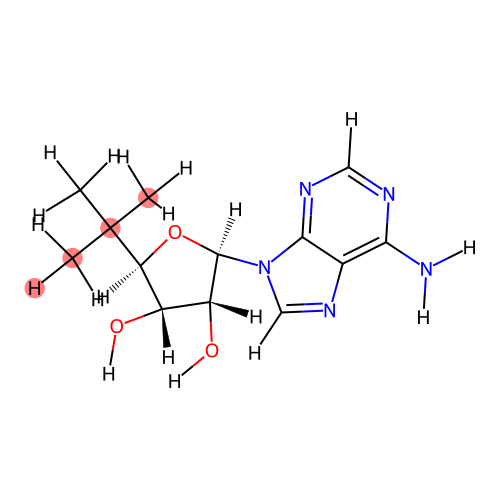

In [13]:
Chem.Draw.MolToImage(mol, size=(500, 500), highlightAtoms=(2, 1, 0, 21), highlightBonds=[])

In [8]:
import pandas as pd
from openbabel import openbabel as ob
from rdkit import Chem
from rdkit.Chem import rdDistGeom, rdForceFieldHelpers, rdMolTransforms, rdDistGeom, rdMolAlign
import os
import subprocess
from pathlib import Path
import numpy as np
from MolSanitizer.amsol import run_amsol
from MolSanitizer.db2 import mol2db2

import logging
logger = logging.getLogger('molsani')

internal_pattern=r'[*;!$([#1])]~[*;!$(*#*)]-&!@[*;!$(*#*)]~[*;!$([#1])]'
terminal_pattern=r'*~[*;!$(*#*)]-[$(A([#1])([#1])[#1]),$(A(F)(F)F),$(A(Cl)(Cl)Cl),$(A(Br)(Br)Br),$(A(I)(I)I)]~[#1,F,Cl,Br,I,CH3]'


def getDihedralMatches(mol, pattern):
    '''return list of atom indices of dihedrals'''
    #this is rdkit's "strict" pattern
    qmol = Chem.MolFromSmarts(pattern)
    matches = mol.GetSubstructMatches(qmol);
    #these are all sets of 4 atoms, uniquify by middle two
    uniqmatches = []
    seen = set()
    for (a,b,c,d) in matches:
        if ((b,c) not in seen) and ((c,b) not in seen):
            seen.add((b,c))
            uniqmatches.append((a,b,c,d))
    return uniqmatches


def check_too_close_nonbonded_atoms(conformer, mol, threshold=1.6):
    """
    Check if any non-bonded atoms in a given conformer are too close to each other.

    Parameters:
    conformer (rdkit.Chem.rdchem.Conformer): The RDKit conformer object.
    mol (rdkit.Chem.Mol): The RDKit molecule object.
    threshold (float): The distance threshold below which atoms are considered too close.

    Returns:
    bool: True if any non-bonded atoms are too close, False otherwise.
    """
    positions = conformer.GetPositions()
    
    # Get the number of atoms in the molecule
    num_atoms = mol.GetNumAtoms()
    
    # Iterate over all pairs of atoms
    for i in range(num_atoms):
        for j in range(i + 1, num_atoms):
            # Check if the atoms are bonded
            if not mol.GetBondBetweenAtoms(i, j):
                # Calculate the distance between the non-bonded atoms
                distance = np.linalg.norm(positions[i] - positions[j])
                if distance < threshold:
                    return True
    return False

def genConformer_terminal_r(mol, conf, i, matches,  sdwriter, product, original, degree = 60, maxconf = 10000):
    '''recursively enumerate all angles for matches dihedrals.  i is where is
    which dihedral we are enumerating by degree to output conformers to out'''
    if len(product) > maxconf: return product
    if i >= len(matches): #base case, torsions should be set in conf
        if check_too_close_nonbonded_atoms(mol.GetConformer(conf), mol): return product
        product.append(Chem.Conformer(mol.GetConformer(conf)))
        sdwriter.write(mol,conf)
        return product
    else:
        deg = rdMolTransforms.GetDihedralDeg(original,*matches[i])
        for idx in range(int(120/degree)): # 120 is the maximum angle for symmetrical terminal dihedrals
            rdMolTransforms.SetDihedralDeg(mol.GetConformer(conf),*matches[i],value = deg + degree*idx)
            product = genConformer_terminal_r(mol, conf, i+1, matches, sdwriter, product, original, degree, maxconf)
        return product
    
def genConformer_internal_r(mol, conf, i, internal_matches, terminal_matches, sdwriter, product, original, degree = 60, maxconf = 10000):
    '''recursively enumerate all angles for matches dihedrals.  i is where is
    which dihedral we are enumerating by degree to output conformers to out'''
    if i >= len(internal_matches): #base case, torsions should be set in conf
        if len(terminal_matches) > 0:
            product = genConformer_terminal_r(mol, conf, 0, terminal_matches, sdwriter, product, original, degree, maxconf)
        else:
            if check_too_close_nonbonded_atoms(mol.GetConformer(conf), mol): return product
            product.append(Chem.Conformer(mol.GetConformer(conf)))
            sdwriter.write(mol,conf)
        return product
    else:
        deg = rdMolTransforms.GetDihedralDeg(original,*internal_matches[i])
        for idx in range(int(360/degree)):
            rdMolTransforms.SetDihedralDeg(mol.GetConformer(conf),*internal_matches[i],value = deg + degree*idx)
            product = genConformer_internal_r(mol, conf, i+1, internal_matches, terminal_matches, sdwriter, product, original, degree, maxconf)
        return product
    
def convert_file(input_file, output_file, input_format, output_format):
    with open(input_file, "r") as f:
        data = f.read()
    converted_data = convert(data, input_format, output_format)
    with open(output_file, "w") as f:
        f.write(converted_data)

def extract_partial_charges(mol2_file, output_file='partialcharges.txt', VERBOSE=False):
    charges = []
    with open(mol2_file, 'r') as f:
        atom_section = False
        for line in f:
            if '@<TRIPOS>ATOM' in line:
                atom_section = True
                continue
            if ('@<TRIPOS>' in line) and ('ATOM' not in line) and (atom_section == True):
                atom_section = False
                break
            if atom_section:
                parts = line.split()
                if len(parts) >= 9:
                    charges.append(float(parts[8]))
    with open(output_file, 'w') as f:
        for charge in charges:
            f.write(f"{charge}\n")
    
    if VERBOSE: print(f"Partial charges extracted and saved to {output_file}")

def assign_charges_and_convert(sdf_file, charges_file, output_mol2):
    # Read charges
    with open(charges_file, 'r') as f:
        charges = [float(line.strip()) for line in f]
    
    # Set up OpenBabel conversion
    obConversion = ob.OBConversion()
    obConversion.SetInAndOutFormats("sdf", "mol2")
        
        # Read all molecules from the SDF file
    mol = ob.OBMol()
    if not obConversion.ReadFile(mol, sdf_file):
        print(f"Error reading SDF file: {sdf_file}")
        return
    unprocessed_mol2_str = ""
    molecule_count = 0
    with open(output_mol2, 'w') as out_file:
        while True:
            molecule_count += 1
            # Assign charges
            for i, atom in enumerate(ob.OBMolAtomIter(mol)):
                if i < len(charges):
                    atom.SetPartialCharge(charges[i])
            mol.SetAutomaticPartialCharge(False)
            mol.SetPartialChargesPerceived()
            
            # Convert molecule to MOL2 format and get as string
            mol2_str = obConversion.WriteString(mol)
            unprocessed_mol2_str+=(mol2_str)
            # Write to output file
            out_file.write(mol2_str)
            
            # Clear the molecule and read the next one
            mol.Clear()
            if not obConversion.Read(mol):
                break
    
    print(f"Converted and saved {molecule_count} conformations to {output_mol2} with assigned charges")
    return unprocessed_mol2_str

def torsional_scan(mol, name, maxconf = 10000, partial_charges='partialcharges.txt'):
    extract_partial_charges(f"{name}.mol2", partial_charges)
    res = Chem.Mol(mol); 
    res.RemoveAllConformers()
    internal_matches = getDihedralMatches(mol, internal_pattern)
    terminal_matches = getDihedralMatches(mol, terminal_pattern)
    #print(rotmatches)
    rotated_file = f"{name}_rotated.sdf"
    sdwriter = Chem.SDWriter(rotated_file)
    product = genConformer_internal_r(mol, conf=0, i=0, internal_matches = internal_matches, terminal_matches = terminal_matches, sdwriter=sdwriter, product=list(), original=mol.GetConformer(0), degree=60, maxconf=maxconf)
    for conf in product:
        res.AddConformer(conf, assignId = True)
    unprocessed_mol2_str = assign_charges_and_convert(rotated_file, partial_charges, f"{name}_rotated.mol2")
    subprocess.run(f"rm {rotated_file}", shell=True)

    return res, unprocessed_mol2_str

In [ ]:
import openbabel

def convert(data, inf, otf):
    mol = openbabel.OBMol()
    convert = openbabel.OBConversion()
    convert.SetInAndOutFormats(inf, otf)
    convert.ReadString(mol, data)
    return convert.WriteString(mol)

convert()

In [ ]:
import openbabel

obConversion = openbabel.OBConversion()
obConversion.SetInAndOutFormats("smi", "mdl")

mol = openbabel.OBMol()
obConversion.ReadString(mol, "C1=CC=CS1")

print(mol.NumAtoms()) #Should print 5 (atoms)

mol.AddHydrogens()
print(mol.NumAtoms()) #Should print 9 (atoms) after adding hydrogens

outMDL = obConversion.WriteString(mol)
print(outMDL) #Should print the MDL molfile

5
9

 OpenBabel07212408522D

  9  9  0  0  0  0  0  0  0  0999 V2000
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 S   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    0.0000    0.0000 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  5  1  0  0  0  0
  1  2  2  0  0  0  0
  1  6  1  0  0  0  0
  2  3  1  0  0  0  0
  2  7  1  0  0  0  0
  3  4  2  0  0  0  0
  3  8  1  0  0  0  0
  4  5  1  0  0  0  0
  4  9  1  0  0  0  0
M  END



/home/phonglam/anaconda3/envs/msani/lib/python3.11/site-packages/openbabel/__init__.py:14: UserWarning: "import openbabel" is deprecated, instead use "from openbabel import openbabel"
  warnings.warn('"import openbabel" is deprecated, instead use "from openbabel import openbabel"')
